# Domains

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cftr
import numpy as np
from matplotlib.lines import Line2D
import cmcrameri
import xarray as xr


In [2]:
orog = xr.open_dataset("Googles_gencast/predictions_output.nc")
print(orog)
# Configuration
variable = '2m_temperature'
map_data = orog.isel(time=0)[variable]

# Define projections
lonlat_proj = ccrs.PlateCarree()
lambert_proj = ccrs.LambertConformal(
    central_longitude=8, 
    central_latitude=50, 
    standard_parallels=(50, 50)
)
lambert_proj.threshold /= 1000

<xarray.Dataset> Size: 22MB
Dimensions:                   (sample: 1, batch: 1, time: 1, lat: 181,
                               lon: 360, level: 13)
Coordinates:
  * sample                    (sample) int32 4B 0
  * time                      (time) timedelta64[ns] 8B 12:00:00
  * lat                       (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * lon                       (lon) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * level                     (level) int32 52B 50 100 150 200 ... 850 925 1000
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind   (sample, batch, time, lat, lon) float32 261kB ...
    10m_v_component_of_wind   (sample, batch, time, lat, lon) float32 261kB ...
    2m_temperature            (sample, batch, time, lat, lon) float32 261kB ...
    mean_sea_level_pressure   (sample, batch, time, lat, lon) float32 261kB ...
    sea_surface_temperature   (sample, batch, time, lat, lon) float32 261kB ...
    total_precipitation_12hr  

In [3]:
# Helper functions for coordinate conversion and optimization
def lonlat_to_grid_indices(lon, lat, maps, grid_spacing=5500):
    """
    Convert lon/lat coordinates to Lambert grid indices.
    
    Parameters:
    -----------
    lon, lat : float or array, longitude and latitude
    grid_spacing : float, grid spacing in meters
    
    Returns:
    --------
    i, j : grid indices
    """
    xs= maps[1]
    ys= maps[0]
    
    # Transform lon/lat to Lambert projection coordinates
    lambert_coords = lambert_proj.transform_point(lon, lat, lonlat_proj)
    x, y = lambert_coords[0], lambert_coords[1]
    
    # Account for centering offset
    x_offset = xs.max() / 2
    y_offset = ys.max() / 2
    
    # Convert to grid indices
    i = (x + x_offset) / grid_spacing
    j = (y + y_offset) / grid_spacing
    
    return i, j

def find_optimal_power2_box(lonm, lonM, latm, latM, maps, grid_spacing=5500, pow=None):
    """
    Find the smallest power-of-2 box in Lambert grid that covers a lon/lat rectangle.
    
    Parameters:
    -----------
    lonm, lonM : float, min and max longitude
    latm, latM : float, min and max latitude
    grid_spacing : float, grid spacing in meters
    
    Returns:
    --------
    im, jm : int, bottom-left grid indices
    powI, powJ : int, powers of 2 for box dimensions
    """
    # Get all four corners in grid coordinates
    corners_i = []
    corners_j = []
    for lon in [lonm, lonM]:
        for lat in [latm, latM]:
            i, j = lonlat_to_grid_indices(lon, lat, maps, grid_spacing)
            corners_i.append(i)
            corners_j.append(j)
    
    # Find bounding box
    i_min, i_max = min(corners_i), max(corners_i)
    j_min, j_max = min(corners_j), max(corners_j)
    
    # Calculate required dimensions
    width = i_max - i_min
    height = j_max - j_min
    
    if not pow:
        # Find smallest power of 2 that fits
        powI = int(np.ceil(np.log2(width)))
        powJ = int(np.ceil(np.log2(height)))
    else:
        powI = pow[0]
        powJ = pow[1]
    
    # Bounding box for DK: [8.09, 54.8, 12.69, 57.73] => center [10.4, 56.3]

    denmark_lon, denmark_lat = 10.4, 56.3
    center_i, center_j = lonlat_to_grid_indices(denmark_lon, denmark_lat, maps)

    im = int(np.floor(center_i - 2**powI / 2))
    jm = int(np.floor(center_j - 2**powJ / 2))
    
    # Print results
    print(f"Lon/Lat box: ({lonm}, {lonM}) × ({latm}, {latM})")
    print(f"Grid indices range: i=[{i_min:.1f}, {i_max:.1f}], j=[{j_min:.1f}, {j_max:.1f}]")
    print(f"Required dimensions: {width:.1f} × {height:.1f} grid cells")
    print(f"Optimal power-of-2 box: 2^{powI} × 2^{powJ} = {2**powI} × {2**powJ}")
    print(f"Bottom-left position: im={im}, jm={jm}")
    print(f"Box covers: i=[{im}, {im+2**powI-1}], j=[{jm}, {jm+2**powJ-1}]")
    
    return im, jm, powI, powJ

# Helper functions for plotting rectangles
def plot_rectangle_lonlat(ax1, ax2, lonm, lonM, latm, latM, color='crimson', 
                          linewidth=2, label=None, label_fontsize=16):
    """
    Plot a rectangle defined in lon/lat coordinates on both axes.
    
    Parameters:
    -----------
    ax1, ax2 : matplotlib axes with cartopy projection
    lonm, lonM : float, min and max longitude
    latm, latM : float, min and max latitude
    color : str, rectangle color
    linewidth : float, line width
    label : str, optional label to display in center
    label_fontsize : float, font size for label
    """
    x = [lonm, lonm, lonM, lonM, lonm]
    y = [latm, latM, latM, latm, latm]
    
    ax1.plot(x, y, c=color, lw=linewidth, transform=lonlat_proj)
    ax2.plot(x, y, c=color, lw=linewidth, transform=lonlat_proj)
    
    if label:
        cx, cy = x[0], y[0]
        ax1.text(cx, cy, label, c=color, fontsize=label_fontsize, 
                ha='left', va='bottom', transform=lonlat_proj)
        ax2.text(cx, cy, label, c=color, fontsize=label_fontsize, 
                ha='left', va='bottom', transform=lonlat_proj)

def plot_rectangle_lambert(ax1, ax2, im, iM, jm, jM, maps, grid_spacing=5500, 
                           color='orange', linewidth=2, label=None, label_fontsize=16):
    """
    Plot a rectangle defined in Lambert grid indices on both axes.
    Grid indices start at (0,0) for bottom-left corner of the map.
    
    Parameters:
    -----------
    ax1, ax2 : matplotlib axes with cartopy projection
    im, iM : int/float, min and max i indices (x-direction)
    jm, jM : int/float, min and max j indices (y-direction)
    grid_spacing : float, grid spacing in meters (default 5500m for CERRA)
    color : str, rectangle color
    linewidth : float, line width
    label : str, optional label to display in center
    label_fontsize : float, font size for label
    """
    xs= maps[1]
    ys= maps[0]
    # Convert grid indices to meters, accounting for centering
    x_offset = xs.max() / 2
    y_offset = ys.max() / 2
    
    xm = im * grid_spacing - x_offset
    xM = iM * grid_spacing - x_offset
    ym = jm * grid_spacing - y_offset
    yM = jM * grid_spacing - y_offset
    
    x = [xm, xm, xM, xM, xm]
    y = [ym, yM, yM, ym, ym]
    
    ax1.plot(x, y, c=color, lw=linewidth, transform=lambert_proj)
    ax2.plot(x, y, c=color, lw=linewidth)
    
    if label:
        cx, cy = x[0], y[0]
        ax1.text(cx, cy, label, c=color, fontsize=label_fontsize, 
                ha='left', va='bottom', transform=lambert_proj)
        ax2.text(cx, cy, label, c=color, fontsize=label_fontsize, 
                ha='left', va='bottom')

In [4]:
print(map_data)
xs = map_data.coords['lon']
ys = map_data.coords['lat']
maps = map_data[0,0,:,:]
transform = lonlat_proj
print(maps.shape)
print(xs.shape)




<xarray.DataArray '2m_temperature' (sample: 1, batch: 1, lat: 181, lon: 360)> Size: 261kB
[65160 values with dtype=float32]
Coordinates:
  * sample   (sample) int32 4B 0
  * lat      (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    time     timedelta64[ns] 8B 12:00:00
Dimensions without coordinates: batch
(181, 360)
(360,)



=== Hortense Northern Domain ===
Lon/Lat box: (5.025, 16.98) × (52.03, 59.98)
Grid indices range: i=[-37.1, 111.9], j=[41.8, 208.7]
Required dimensions: 149.0 × 166.8 grid cells
Optimal power-of-2 box: 2^8 × 2^8 = 256 × 256
Bottom-left position: im=-101, jm=0
Box covers: i=[-101, 154], j=[0, 255]


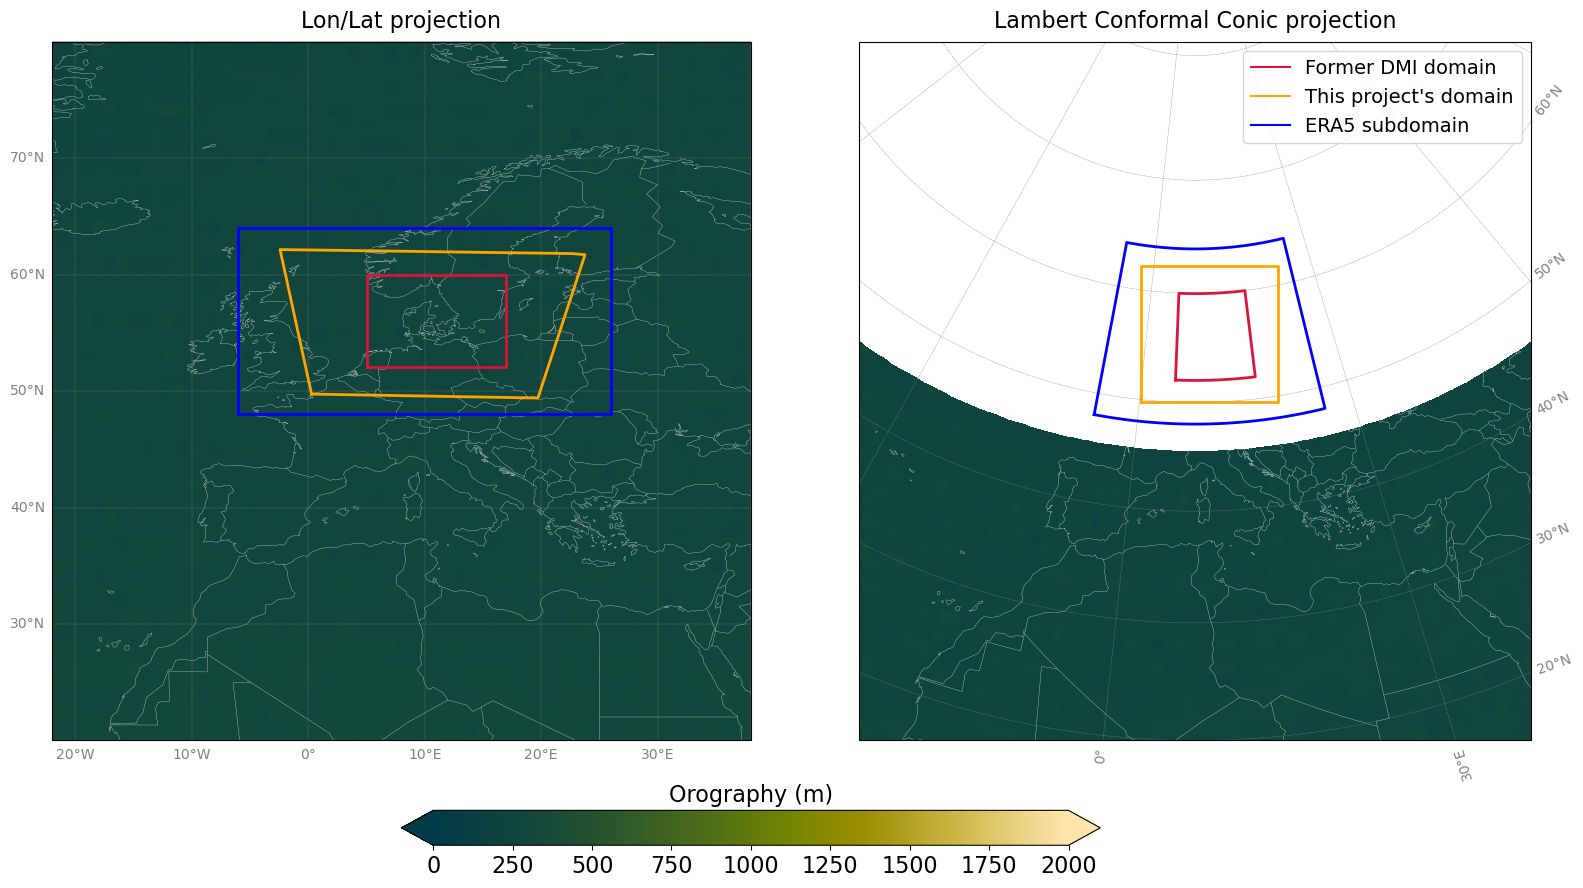

In [5]:
# Create figure with side-by-side layout
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 0.5], width_ratios=[1, 1])
gs.update(wspace=0.05, hspace=0.15)

# Left panel: Lon/Lat projection
ax1 = fig.add_subplot(gs[0, 0], projection=lonlat_proj)
g1 = ax1.gridlines(draw_labels=True, linestyle='--', color='grey', dms=True,
                   x_inline=False, y_inline=False, linewidth=0.3)
g1.right_labels = False
g1.top_labels = False
g1.xlabel_style = {'size': 10, 'color': 'grey'}
g1.ylabel_style = {'size': 10, 'color': 'grey'}

im1 = ax1.pcolormesh(xs, ys, maps, 
                     vmin=0, vmax=2000, 
                     cmap=cmcrameri.cm.bamako,
                     transform=transform)

ax1.coastlines(resolution='50m', color='w', lw=0.2)
ax1.add_feature(cftr.BORDERS, ec='w', lw=0.2)
ax1.set_title('Lon/Lat projection', fontsize=16, pad=10)

# Right panel: Lambert Conformal projection
ax2 = fig.add_subplot(gs[0, 1], projection=lambert_proj)
g2 = ax2.gridlines(draw_labels=True, linestyle='--', color='grey', dms=True,
                   x_inline=False, y_inline=False, linewidth=0.3)
g2.left_labels = False
g2.top_labels = False
g2.xlabel_style = {'size': 10, 'color': 'grey'}
g2.ylabel_style = {'size': 10, 'color': 'grey'}

im2 = ax2.pcolormesh(xs - xs.max()/2, 
                     ys - ys.max()/2, 
                     maps,
                     vmin=0, vmax=2000, 
                     cmap=cmcrameri.cm.bamako,
                     transform=transform)

ax2.coastlines(resolution='50m', color='w', lw=0.2)
ax2.add_feature(cftr.BORDERS, ec='w', lw=0.2)
ax2.set_title('Lambert Conformal Conic projection', fontsize=16, pad=10)

# Colorbar at bottom
cax = ax1.inset_axes([0.5, -0.15, 1, 0.05])
cbar = fig.colorbar(im1, cax=cax, orientation='horizontal', extend='both')
cbar.ax.xaxis.set_label_position('bottom')
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_title('Orography (m)', fontsize=16)

# Northern Hortense domain
# Define lon/lat rectangle
nh_lonm, nh_lonM = 5.025, 16.98
nh_latm, nh_latM = 52.03, 59.98

# Find optimal power-of-2 box
print("\n=== Hortense Northern Domain ===")
nh_im, nh_jm, nh_powI, nh_powJ = find_optimal_power2_box(
    nh_lonm, nh_lonM, nh_latm, nh_latM, maps
)

handles = []

# Domain Hortense
plot_rectangle_lonlat(ax1, ax2, 
                      lonm=nh_lonm, lonM=nh_lonM, 
                      latm=nh_latm, latM=nh_latM,
                      color='crimson', linewidth=2)
handles.append(Line2D([0], [0], label='Former DMI domain', color='crimson'))

# Domain Luc
plot_rectangle_lambert(ax1, ax2,
                       im=nh_im, iM=nh_im + 2**nh_powI-1,
                       jm=nh_jm, jM=nh_jm + 2**nh_powJ-1, maps=maps,
                       color='orange', linewidth=2)
handles.append(Line2D([0], [0], label='This project\'s domain', color='orange'))

# ERA5 subdomain for cropping before remapping
plot_rectangle_lonlat(ax1, ax2, 
                      lonm=-6, lonM=26, 
                      latm=48, latM=64,
                      color='blue', linewidth=2)
handles.append(Line2D([0], [0], label='ERA5 subdomain', color='blue'))

lonlat_coverage = 30
ax1.set_xlim((8-lonlat_coverage, 8+lonlat_coverage))
ax1.set_ylim((50-lonlat_coverage, 50+lonlat_coverage))

ax2.legend(handles=handles, loc='upper right', fontsize=14)

extent = [8 - lonlat_coverage, 8 + lonlat_coverage, 50 - lonlat_coverage, 50 + lonlat_coverage]
ax1.set_extent(extent, crs=lonlat_proj)
ax2.set_extent(extent, crs=lonlat_proj)

plt.savefig("plot.png")
plt.show()

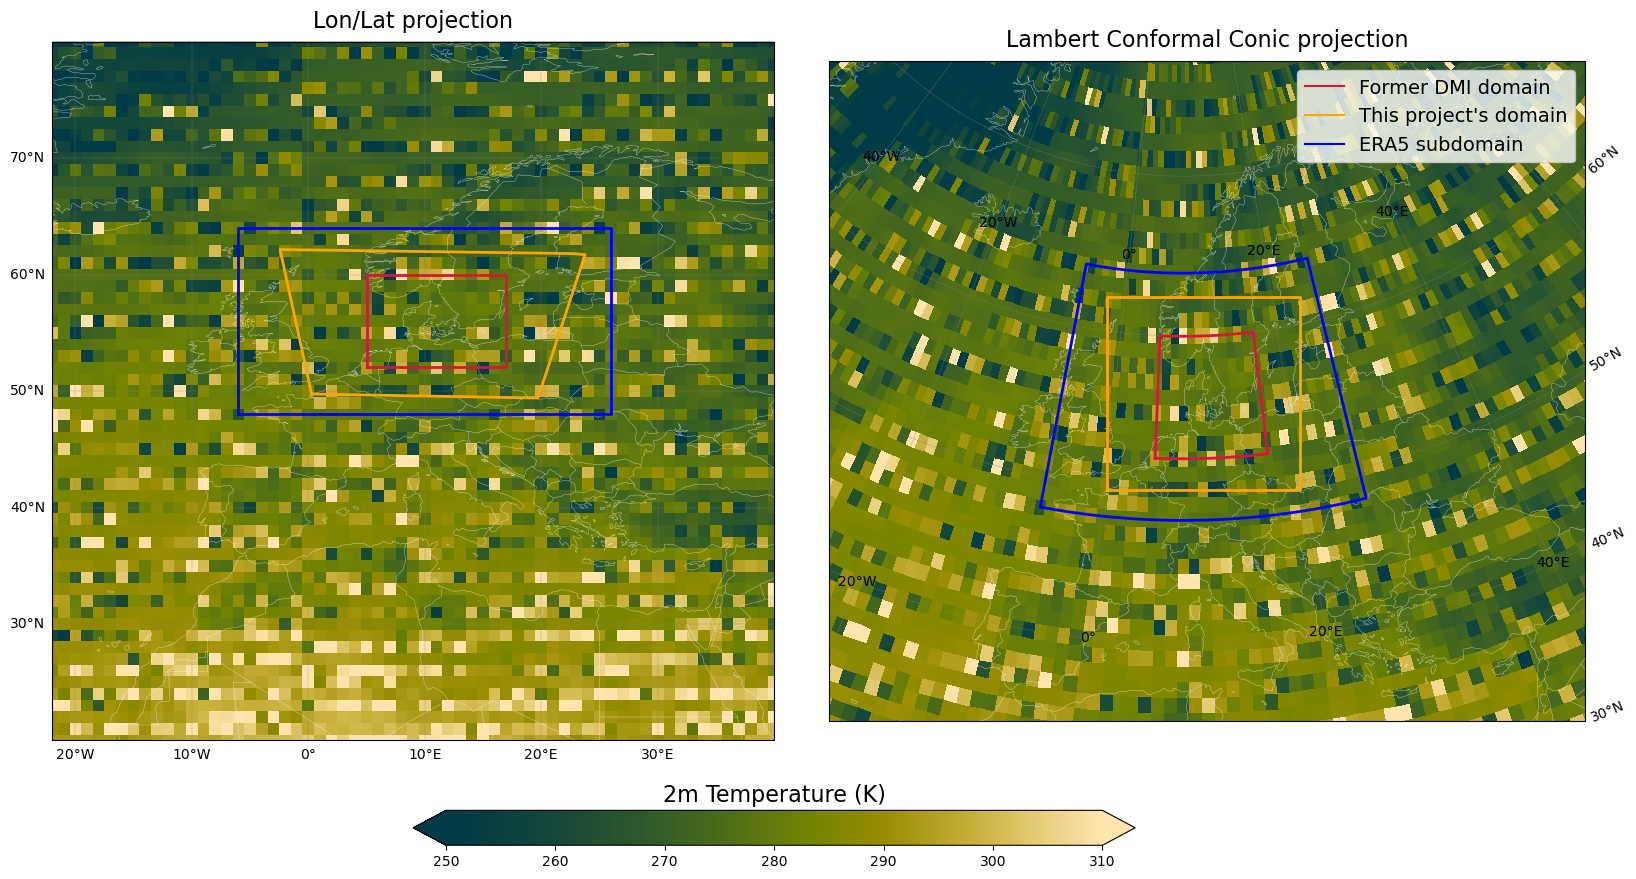

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cftr
import numpy as np
import cmcrameri
from matplotlib.lines import Line2D


# Load the NetCDF dataset containing the weather predictions
orog = xr.open_dataset("Googles_gencast/predictions_output.nc")

# 

map_data = orog.isel(time=0)['2m_temperature']
maps = map_data[0, 0, :, :]

# Extract longitude and latitude coordinates directly from the dataset
xs = map_data.coords['lon']
ys = map_data.coords['lat']

# Define the projection for the original data coordinates
lonlat_proj = ccrs.PlateCarree()

# Define the target Lambert Conformal Conic projection for the right panel
lambert_proj = ccrs.LambertConformal(
    central_longitude=8, 
    central_latitude=50, 
    standard_parallels=(50, 50)
)
# Adjust threshold to prevent plotting artifacts in Cartopy
lambert_proj.threshold /= 1000

def lonlat_to_grid_indices(lon, lat, grid_spacing=5500):
    # Convert raw longitude and latitude into Lambert projected coordinates
    lambert_coords = lambert_proj.transform_point(lon, lat, lonlat_proj)
    # Divide by grid spacing to get grid index values
    return lambert_coords[0] / grid_spacing, lambert_coords[1] / grid_spacing

def find_optimal_power2_box(lonm, lonM, latm, latM, grid_spacing=5500, pow=None):
    # Calculate the grid indices for all four corners of the requested bounding box
    corners_i, corners_j = [], []
    for lon in [lonm, lonM]:
        for lat in [latm, latM]:
            i, j = lonlat_to_grid_indices(lon, lat, grid_spacing)
            corners_i.append(i)
            corners_j.append(j)
    
    # Find the absolute minimum and maximum indices to form a grid-aligned box
    i_min, i_max = min(corners_i), max(corners_i)
    j_min, j_max = min(corners_j), max(corners_j)
    
    # Determine the total width and height of the box in grid cells
    width = i_max - i_min
    height = j_max - j_min
    
    # Calculate the nearest power of 2 that can fit the requested box dimensions
    if not pow:
        powI = int(np.ceil(np.log2(width)))
        powJ = int(np.ceil(np.log2(height)))
    else:
        powI, powJ = pow[0], pow[1]

    # Center the new power-of-2 box over Denmark
    center_i, center_j = lonlat_to_grid_indices(10.4, 56.3, grid_spacing)
    im = int(np.floor(center_i - 2**powI / 2))
    jm = int(np.floor(center_j - 2**powJ / 2))
    
    return im, jm, powI, powJ

def plot_rectangle_lonlat(ax1, ax2, lonm, lonM, latm, latM, color='crimson', linewidth=2):
    # Create a closed loop of coordinates for the rectangle
    x = [lonm, lonm, lonM, lonM, lonm]
    y = [latm, latM, latM, latm, latm]
    # Draw the rectangle on both axes using the base PlateCarree projection
    ax1.plot(x, y, c=color, lw=linewidth, transform=lonlat_proj)
    ax2.plot(x, y, c=color, lw=linewidth, transform=lonlat_proj)

def plot_rectangle_lambert(ax1, ax2, im, iM, jm, jM, grid_spacing=5500, color='orange', linewidth=2):
    # Convert grid indices back into meters for plotting on the Lambert projection
    xm = im * grid_spacing
    xM = iM * grid_spacing
    ym = jm * grid_spacing
    yM = jM * grid_spacing
    
    # Create a closed loop of coordinates for the grid-aligned rectangle
    x = [xm, xm, xM, xM, xm]
    y = [ym, yM, yM, ym, ym]
    # Draw the rectangle on both axes using the Lambert projection
    ax1.plot(x, y, c=color, lw=linewidth, transform=lambert_proj)
    ax2.plot(x, y, c=color, lw=linewidth, transform=lambert_proj)

# Initialize the main figure and layout grid
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 0.5], width_ratios=[1, 1])
gs.update(wspace=0.05, hspace=0.15)

# Set up the left panel with a standard unprojected latitude and longitude view
ax1 = fig.add_subplot(gs[0, 0], projection=lonlat_proj)
g1 = ax1.gridlines(draw_labels=True, linestyle='--', color='grey', linewidth=0.3)
g1.right_labels = False
g1.top_labels = False

# Plot the 2m temperature data using Kelvin limits (250 to 310)
im1 = ax1.pcolormesh(xs, ys, maps, vmin=250, vmax=310, cmap=cmcrameri.cm.bamako, transform=lonlat_proj,shading='nearest')

ax1.coastlines(resolution='50m', color='w', lw=0.2)
ax1.add_feature(cftr.BORDERS, ec='w', lw=0.2)
ax1.set_title('Lon/Lat projection', fontsize=16, pad=10)

# Set up the right panel with the Lambert Conformal projection
ax2 = fig.add_subplot(gs[0, 1], projection=lambert_proj)
g2 = ax2.gridlines(draw_labels=True, linestyle='--', color='grey', linewidth=0.3)
g2.left_labels = False
g2.top_labels = False

# Plot the same temperature data mapped onto the Lambert projection
im2 = ax2.pcolormesh(xs, ys, maps, vmin=250, vmax=310, cmap=cmcrameri.cm.bamako, transform=lonlat_proj, shading='nearest')

ax2.coastlines(resolution='50m', color='w', lw=0.2)
ax2.add_feature(cftr.BORDERS, ec='w', lw=0.2)
ax2.set_title('Lambert Conformal Conic projection', fontsize=16, pad=10)

# Add a horizontal colorbar scaled for temperature
cax = ax1.inset_axes([0.5, -0.15, 1, 0.05])
cbar = fig.colorbar(im1, cax=cax, orientation='horizontal', extend='both')
cbar.ax.set_title('2m Temperature (K)', fontsize=16)

# Define the coordinates for the Northern Hortense domain
nh_lonm, nh_lonM = 5.025, 16.98
nh_latm, nh_latM = 52.03, 59.98

# Calculate the exact grid indices for the power-of-2 box
nh_im, nh_jm, nh_powI, nh_powJ = find_optimal_power2_box(nh_lonm, nh_lonM, nh_latm, nh_latM)

# Draw all the domain rectangles and build the legend
handles = []
plot_rectangle_lonlat(ax1, ax2, lonm=nh_lonm, lonM=nh_lonM, latm=nh_latm, latM=nh_latM, color='crimson')
handles.append(Line2D([0], [0], label='Former DMI domain', color='crimson'))

plot_rectangle_lambert(ax1, ax2, im=nh_im, iM=nh_im + 2**nh_powI-1, jm=nh_jm, jM=nh_jm + 2**nh_powJ-1, color='orange')
handles.append(Line2D([0], [0], label="This project's domain", color='orange'))

plot_rectangle_lonlat(ax1, ax2, lonm=-6, lonM=26, latm=48, latM=64, color='blue')
handles.append(Line2D([0], [0], label='ERA5 subdomain', color='blue'))



# Restrict the view of both maps to the relevant European region
ax1.set_extent([-22, 40, 20, 80], crs=lonlat_proj)
ax2.set_extent([-20, 40, 35, 75], crs=lonlat_proj)

# Display the final legend and render the plot
ax2.legend(handles=handles, loc='upper right', fontsize=14)
plt.show()
# ok no this needs to be corrected. first not a class but a function second. i dont need the squares i just need projection type and domain size, third i need to chose the varible to be plotted and the color bar should be constant between the two projections.